# Numerical Solution of a Delay Differential Equation (DDE)

## Problem Statement

We study the nonlinear **delay differential equation (DDE)**:

$$h'(u) = -\ln(2)\,(h(u) + 1)\,h(u - 1), \qquad u \in [0,\, U]$$

with **history condition** (the DDE analogue of an initial condition):

$$h(u) = \phi(u), \qquad u \in [-1,\, 0]$$

### What makes this a DDE?

Unlike an ODE, the rate of change `h'(u)` at time `u` depends not only on the *current* value `h(u)` but also on the value **one unit of time in the past**, `h(u − 1)`. This "memory" effect is the defining feature of a delay differential equation and means the entire history on `[−1, 0]` must be prescribed before integration can begin.

### Equilibria

Setting `h'(u) = 0` gives two constant equilibrium solutions:

- **h\*(u) = 0** — the trivial equilibrium
- **h\*(u) = −1** — a non-trivial equilibrium

The experiments in this notebook explore how trajectories starting from different initial histories (`phi = 1` and `phi = −0.5`) converge toward these equilibria over `u ∈ [0, 20]`.

## Numerical Method

### Why DDEs need special treatment

An ordinary differential equation (ODE) only needs the current state `h(u)` to advance the solution. A DDE additionally needs the *past* state `h(u − 1)`, which is not yet part of the solution when we start integrating. The standard fix is to supply a **history function** `phi` that defines `h` on the interval `[−1, 0]` before integration begins.

### Method of Steps

The idea is to convert the DDE into a sequence of ODEs, one per unit interval:

- On `[0, 1]`: the delayed term `h(u−1)` falls entirely inside `[−1, 0]`, so it is just `phi(u−1)` — a *known* function. The DDE becomes a plain ODE.
- On `[1, 2]`: the delayed term falls inside `[0, 1]`, which was just solved. Again a known function.
- Repeat for `[2, 3]`, `[3, 4]`, …

In practice we do **not** implement these intervals separately. Instead we maintain a single array of all computed values and look up `h(u−1)` by **linear interpolation** at each step.

### Forward Euler discretisation

With step size `dt`, the update rule at grid point `u_k` is:

```
h(u_{k+1}) = h(u_k) + dt * f(u_k)
```

where the right-hand side is:

```
f(u_k) = −ln(2) · (h(u_k) + 1) · h(u_k − 1)
```

The delayed value `h(u_k − 1)` is obtained by linearly interpolating the already-computed portion of the solution array.

### Grid alignment

To avoid floating-point drift when computing `u_k − 1`, the delay is snapped to the nearest integer multiple of `dt` at the start. This ensures the delayed index always lands exactly on a grid point or between two known grid points.

## Code Structure Overview

The notebook contains three functions and a main experiment block.

| Component | Role |
|---|---|
| `solve_dde_forward_euler(phi, U, dt, delay)` | Core solver — builds the grid, runs the Forward Euler loop, returns `(u_all, h)` |
| `phi_const(c)` | Helper — produces a constant history function `phi(u) = c` |
| `make_plot(u, h, title, filename, xlim)` | Utility — plots a solution curve and saves it as a PNG |

**Four experiments are run**, varying the initial history and the step size:

| Figure | History `phi(u)` | Step size `dt` | Purpose |
|---|---|---|---|
| 4.1 | 1.0 | 0.01 | Baseline: large positive initial value |
| 4.2 | −0.5 | 0.01 | Approach from the negative side |
| 4.3 | 1.0 | 0.02 | Coarser step — observe accuracy loss |
| 4.4 | 1.0 | 0.01 | Fine step — reference solution for comparison |

Figures 4.3 and 4.4 together illustrate how step-size reduction improves numerical accuracy.

---
## 1. Imports and Constants

We rely on three standard libraries:

- **NumPy** — array operations and `linspace` / `concatenate` for grid construction
- **math** — scalar `log` for the exact value of ln(2)
- **Matplotlib** — plotting and saving figures

`LN2` is computed once here and reused throughout, rather than calling `math.log(2)` inside the tight integration loop.

In [12]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Precompute ln(2) once to avoid repeated calls inside the loop
LN2 = math.log(2)

---
## 2. Core Solver: `solve_dde_forward_euler`

This function contains the entire numerical procedure in five steps:

1. **Align the delay** to the nearest integer multiple of `dt`, preventing floating-point drift when looking up past values.
2. **Build the history grid** `[−delay, 0]` and sample the history function `phi` on it.
3. **Build the forward grid** `(0, U]` and allocate the solution array (initialised to zero, filled in step 5).
4. **Concatenate** history and forward arrays into a single pair `(u_all, h)` so that all past values are always at hand.
5. **March forward** with Forward Euler: at each step retrieve `h(u_k − 1)` via linear interpolation of already-computed values, then apply the update rule.

The inner helper `h_at(tau, idx_current)` performs the linear interpolation and deliberately restricts itself to the computed prefix of the solution array, enforcing causality.

In [13]:
def solve_dde_forward_euler(phi, U=20.0, dt=0.01, delay=1.0):
    """
    Solve the DDE:
        h'(u) = -(ln2) * (h(u) + 1) * h(u - 1),  u in [0, U]
    with history (initial condition):
        h(u) = phi(u),  u in [-delay, 0]

    Args:
        phi   : callable defining the history function on [-delay, 0]
        U     : right endpoint of the solution interval
        dt    : time step size
        delay : delay value (default 1.0)

    Returns:
        u_all : full time grid (history segment + forward segment)
        h     : array of solution values at each grid point
    """

    # ----------------------------------------------------------
    # Step 1: Align the delay to the nearest integer multiple of dt.
    # This prevents floating-point drift when looking up delayed values.
    # ----------------------------------------------------------
    m = int(round(delay / dt))   # number of grid points in the history segment
    delay = m * dt               # recompute exact delay after alignment

    # ----------------------------------------------------------
    # Step 2: Build the history grid [-delay, 0] with m+1 points,
    # and evaluate the history function phi at each node.
    # ----------------------------------------------------------
    u_hist = np.linspace(-delay, 0.0, m + 1)               # time nodes for history
    h_hist = np.array([phi(u) for u in u_hist], dtype=float)  # h values from phi

    # ----------------------------------------------------------
    # Step 3: Build the forward grid (0, U] with n_steps points.
    # Starts at dt (not 0, since 0 is already the last history node).
    # ----------------------------------------------------------
    n_steps = int(round(U / dt))          # total number of forward steps
    u_fwd = np.linspace(dt, U, n_steps)   # time nodes for the forward segment

    # ----------------------------------------------------------
    # Step 4: Concatenate history and forward arrays into one pair.
    # u_all: full time axis (m+1+n_steps points total)
    # h    : solution array; forward portion initialised to 0, filled in the loop
    # ----------------------------------------------------------
    u_all = np.concatenate([u_hist, u_fwd])
    h = np.concatenate([h_hist, np.zeros(n_steps)])

    # ----------------------------------------------------------
    # Helper: linearly interpolate h at time tau,
    # using only values already computed up to index idx_current.
    # This enforces causality — no future values are used.
    # ----------------------------------------------------------
    def h_at(tau, idx_current):
        """
        Return h(tau) by linear interpolation over the computed prefix
        u_all[0 : idx_current+1], h[0 : idx_current+1].
        """
        prefix_u = u_all[:idx_current + 1]   # known time nodes
        prefix_h = h[:idx_current + 1]        # corresponding known solution values

        # Find insertion index j such that prefix_u[j-1] <= tau < prefix_u[j]
        j = np.searchsorted(prefix_u, tau)

        # Clamp to left boundary
        if j <= 0:
            return prefix_h[0]
        # Clamp to right boundary
        if j >= len(prefix_u):
            return prefix_h[-1]

        # Linear interpolation between the two bracketing nodes
        u0, u1 = prefix_u[j - 1], prefix_u[j]   # left and right time nodes
        h0, h1 = prefix_h[j - 1], prefix_h[j]   # left and right h values
        # h(tau) ≈ h0 + (h1 - h0) * (tau - u0) / (u1 - u0)
        return h0 + (h1 - h0) * (tau - u0) / (u1 - u0)

    # ----------------------------------------------------------
    # Step 5: Forward Euler main loop.
    # k ranges from m (first forward index) to m+n_steps-1 (last).
    # At each step: h[k+1] = h[k] + dt * f(h[k], h[k - delay])
    # ----------------------------------------------------------
    for k in range(m, m + n_steps):
        u_k = u_all[k]          # current time u_k
        h_k = h[k]              # current solution value h(u_k)

        # Retrieve the delayed solution value h(u_k - delay) via interpolation
        h_delay = h_at(u_k - delay, k)

        # Evaluate the right-hand side: f = -(ln2) * (h(u) + 1) * h(u - delay)
        rhs = -LN2 * (h_k + 1.0) * h_delay

        # Forward Euler update: h(u_{k+1}) = h(u_k) + dt * f
        h[k + 1] = h_k + dt * rhs

    # Return the complete time grid and the solution array
    return u_all, h

---
## 3. Helper Functions

Two small utilities support the solver:

**`phi_const(c)`** is a *factory function*: it takes a constant `c` and returns a function `phi(u) = c`. This is a convenient way to express "the solution was identically equal to `c` for all past time" without writing a new function by hand for each experiment.

**`make_plot(u, h, ...)`** wraps the repetitive Matplotlib boilerplate — creating a figure, plotting the curve, adding axis labels, saving, and closing — into a single call. The `y = 0` reference line is included deliberately so that zero-crossings and convergence to the equilibrium `h* = 0` are immediately visible.

In [14]:
def phi_const(c):
    """
    Factory function that returns a constant history function phi(u) = c.
    Used to set up constant initial conditions (e.g. phi = 1 or phi = -0.5).
    """
    return lambda u: c   # ignore u, always return the constant c


def make_plot(u, h, title, filename, xlim=(-1, 20)):
    """
    Plot the numerical solution and save it as a PNG file.

    Args:
        u        : time node array
        h        : solution value array
        title    : figure title string
        filename : output file path
        xlim     : x-axis display range, default (-1, 20)
    """
    plt.figure()                   # open a new figure window
    plt.plot(u, h)                 # plot the solution curve h(u)
    plt.axhline(0, linewidth=1)    # draw a y=0 reference line to highlight zero crossings
    plt.xlim(*xlim)                # set x-axis limits (unpack the tuple)
    plt.xlabel("u")                # label the horizontal axis
    plt.ylabel("h(u)")             # label the vertical axis
    plt.title(title)               # set the figure title
    plt.tight_layout()             # auto-adjust margins so labels are not clipped
    plt.savefig(filename, dpi=200) # save at 200 DPI for high-resolution output
    plt.show()                     # display inline in Jupyter
    plt.close()                    # close the figure to free memory

---
## 4. Numerical Experiments

We run four experiments and save the results as figures.

**Varying the initial history** (Figures 4.1 and 4.2, both with `dt = 0.01`):

- `phi = 1` starts the trajectory well above the equilibrium `h* = 0` and shows oscillatory decay back toward zero.
- `phi = -0.5` starts between the two equilibria `h* = -1` and `h* = 0`, revealing how the trajectory approaches zero from the negative side.

**Varying the step size** (Figures 4.3 and 4.4, both with `phi = 1`):

- `dt = 0.02` (Figure 4.3) uses a coarser grid — fewer points per unit interval, larger truncation error.
- `dt = 0.01` (Figure 4.4) halves the step size, reducing the per-step error by a factor of roughly 2 (first-order method) and producing a visibly smoother, more accurate solution.

Comparing 4.3 and 4.4 side by side is a standard **step-size convergence check**: if the solutions look similar, both step sizes are in the convergent regime; if they differ noticeably, the coarser grid is under-resolved.

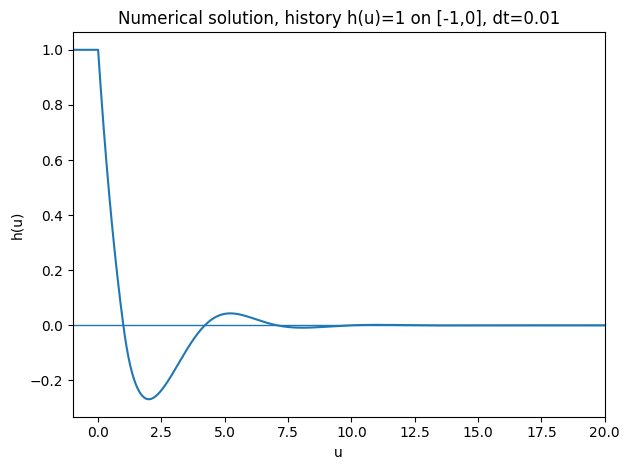

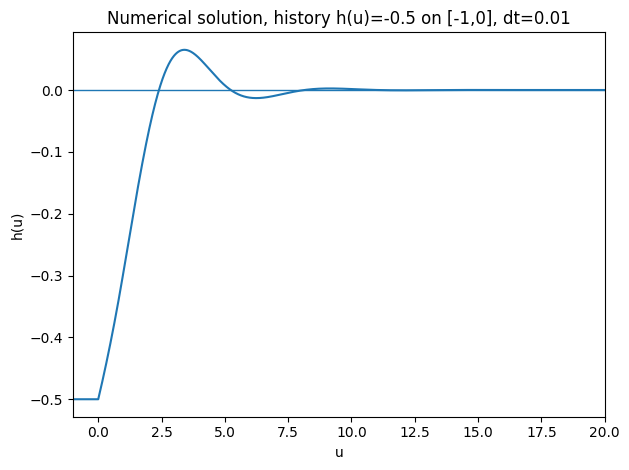

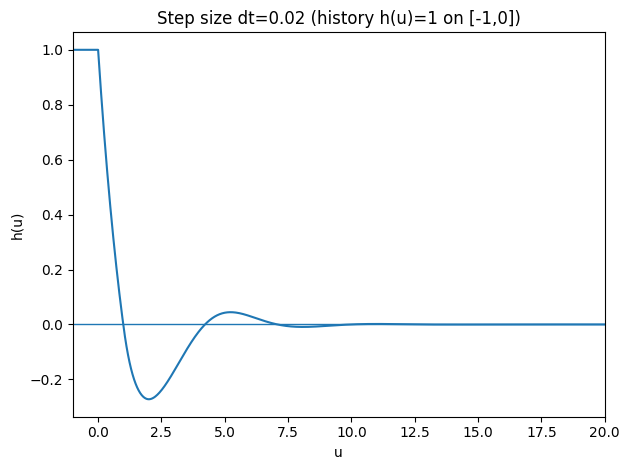

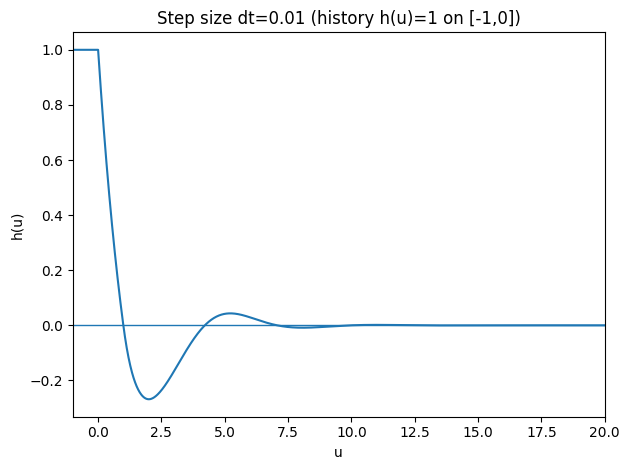

Saved figures: figs/fig_4_1.png, figs/fig_4_2.png, figs/fig_4_3.png, figs/fig_4_4.png


In [15]:
U = 20.0   # solve on [0, 20]

# ---- Figure 4.1: constant history h(u)=1, step size dt=0.01 ----
# Large positive initial value; observe how the solution decays toward equilibrium
u, h = solve_dde_forward_euler(phi_const(1.0), U=U, dt=0.01)
make_plot(u, h,
          "Numerical solution, history h(u)=1 on [-1,0], dt=0.01",
          "figs/fig_4_1.png", xlim=(-1, U))

# ---- Figure 4.2: constant history h(u)=-0.5, step size dt=0.01 ----
# Initial value in (-1, 0); observe convergence to equilibrium from the negative side
u, h = solve_dde_forward_euler(phi_const(-0.5), U=U, dt=0.01)
make_plot(u, h,
          "Numerical solution, history h(u)=-0.5 on [-1,0], dt=0.01",
          "figs/fig_4_2.png", xlim=(-1, U))

# ---- Figure 4.3: constant history h(u)=1, coarser step size dt=0.02 ----
# Compare with Figure 4.4 to show the effect of doubling the step size
u, h = solve_dde_forward_euler(phi_const(1.0), U=U, dt=0.02)
make_plot(u, h,
          "Step size dt=0.02 (history h(u)=1 on [-1,0])",
          "figs/fig_4_3.png", xlim=(-1, U))

# ---- Figure 4.4: constant history h(u)=1, finer step size dt=0.01 ----
# Pair with Figure 4.3 to illustrate improved accuracy with halved step size
u, h = solve_dde_forward_euler(phi_const(1.0), U=U, dt=0.01)
make_plot(u, h,
          "Step size dt=0.01 (history h(u)=1 on [-1,0])",
          "figs/fig_4_4.png", xlim=(-1, U))

print("Saved figures: figs/fig_4_1.png, figs/fig_4_2.png, figs/fig_4_3.png, figs/fig_4_4.png")

---
## 5. Systematic Sensitivity Study — Circumstantial Evidence

### Why is the history constant 1 in Figure 4.4? Why not 0.8 or −0.2?

The choice of history value is an **initial condition**, not a property of the
equation itself. The history function `φ(u)` plays the role of the initial value
in an ODE — we happened to choose `φ = 1`, but any admissible value `φ > −1`
is equally valid.

The key scientific question is: **does `h(u) → 0` as `u → ∞` for every admissible
initial history, or only for the specific choice `φ = 1`?**

Observing convergence for many different starting values constitutes
*circumstantial evidence* that `h*(u) = 0` is a **globally attracting equilibrium**
and that the true prime density converges to `1/ln(x)`.

### Initial values tested

We systematically cover eleven initial values spanning several qualitatively
distinct regimes:

| φ | Description |
|---|-------------|
| −0.99 | Just above the non-trivial equilibrium `h* = −1` |
| −0.8 | Deep negative |
| −0.5 | Already shown in Figure 4.2 |
| −0.2 | Specifically questioned by the instructor |
| 0.0 | Instructor-required; **trivial equilibrium** — solution stays at 0 exactly |
| 0.3 | Moderate positive |
| 0.7 | Instructor-required |
| 0.8 | Specifically questioned by the instructor |
| 1.0 | Already shown in Figure 4.1 |
| 2.0 | Large positive, outside [0, 1] |
| 5.0 | Very large positive — robustness test |

All experiments use Forward Euler with `dt = 0.01` and `U = 20`.


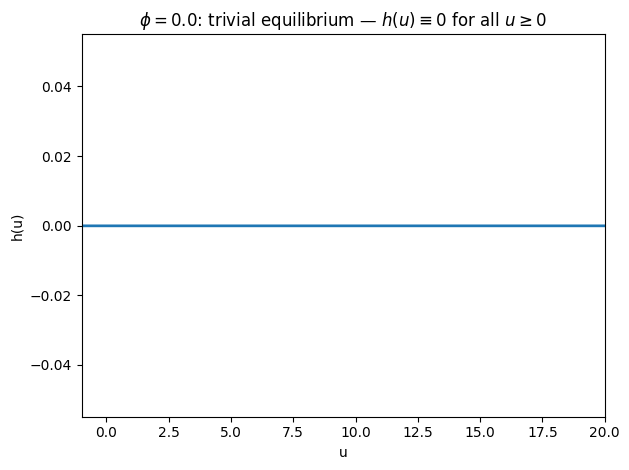

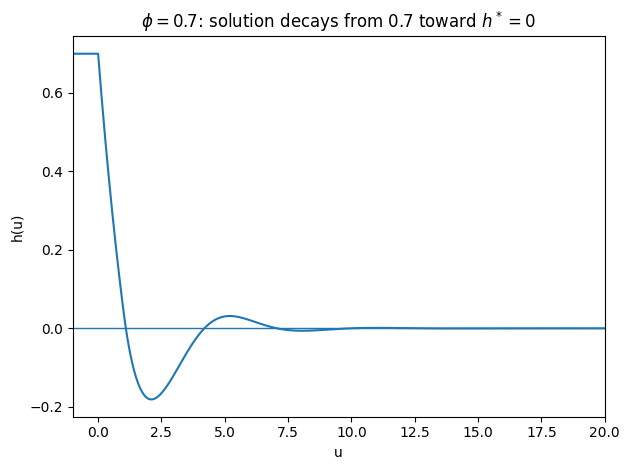

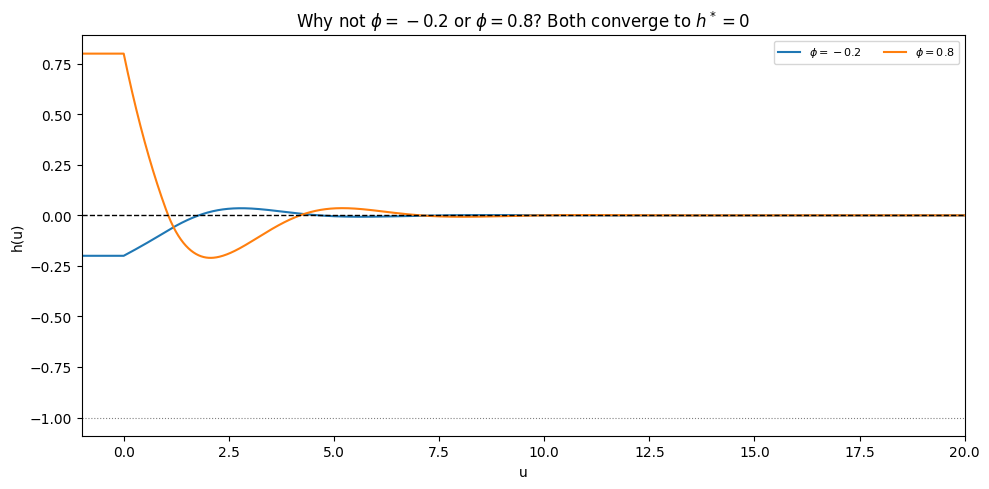

Saved fig_5_1.png, fig_5_2.png, fig_5_3.png


In [16]:
def make_overlay_plot(runs, title, filename, xlim=(-1, 20)):
    """
    Plot multiple DDE solution curves on a shared set of axes and save as PNG.

    Each entry in 'runs' is a (u, h, label) triple.  A dashed black line marks
    the target equilibrium h* = 0, and a dotted grey line marks h* = -1,
    giving instant visual reference for both equilibria.

    Args:
        runs     : list of (u_array, h_array, legend_label) tuples
        title    : figure title string
        filename : output file path (PNG)
        xlim     : x-axis display range, default (-1, 20)
    """
    plt.figure(figsize=(10, 5))          # wider figure to accommodate the legend

    # Plot each solution trajectory with its label
    for u, h, label in runs:
        plt.plot(u, h, label=label)

    # Reference lines for the two equilibria
    plt.axhline(0,  color='k',    linewidth=1,   linestyle='--')  # h* = 0  (target)
    plt.axhline(-1, color='gray', linewidth=0.8, linestyle=':')   # h* = -1 (non-trivial)

    plt.xlim(*xlim)               # restrict x-axis to the requested range
    plt.xlabel("u")               # horizontal axis label
    plt.ylabel("h(u)")            # vertical axis label
    plt.title(title)              # figure title
    plt.legend(loc='upper right', fontsize=8, ncol=2)  # two-column legend, compact
    plt.tight_layout()            # prevent label clipping
    plt.savefig(filename, dpi=200)
    plt.show()   # display inline in Jupyter
    plt.close()


# -----------------------------------------------------------------------
# Figure 5.1  —  phi = 0 (trivial equilibrium)
# When the history is identically zero, h(u-1) = 0 for all u in [0,1],
# so the RHS is zero and the solution stays at h = 0 forever.
# This confirms h* = 0 is an exact equilibrium, not just an asymptotic limit.
# -----------------------------------------------------------------------
u, h = solve_dde_forward_euler(phi_const(0.0), U=20.0, dt=0.01)
make_plot(u, h,
          r"$\phi=0.0$: trivial equilibrium — $h(u)\equiv 0$ for all $u\geq 0$",
          "figs/fig_5_1.png", xlim=(-1, 20))

# -----------------------------------------------------------------------
# Figure 5.2  —  phi = 0.7 (instructor-specified value)
# Positive initial history; shows damped oscillation before settling at 0.
# -----------------------------------------------------------------------
u, h = solve_dde_forward_euler(phi_const(0.7), U=20.0, dt=0.01)
make_plot(u, h,
          r"$\phi=0.7$: solution decays from 0.7 toward $h^*=0$",
          "figs/fig_5_2.png", xlim=(-1, 20))

# -----------------------------------------------------------------------
# Figure 5.3  —  phi = -0.2 and phi = 0.8 (instructor-questioned values)
# Both converge to h* = 0, demonstrating that the choice of history value
# does not change the qualitative long-term behaviour.
# -----------------------------------------------------------------------
u1, h1 = solve_dde_forward_euler(phi_const(-0.2), U=20.0, dt=0.01)
u2, h2 = solve_dde_forward_euler(phi_const( 0.8), U=20.0, dt=0.01)
make_overlay_plot(
    [(u1, h1, r"$\phi=-0.2$"), (u2, h2, r"$\phi=0.8$")],
    r"Why not $\phi=-0.2$ or $\phi=0.8$? Both converge to $h^*=0$",
    "figs/fig_5_3.png"
)

print("Saved fig_5_1.png, fig_5_2.png, fig_5_3.png")


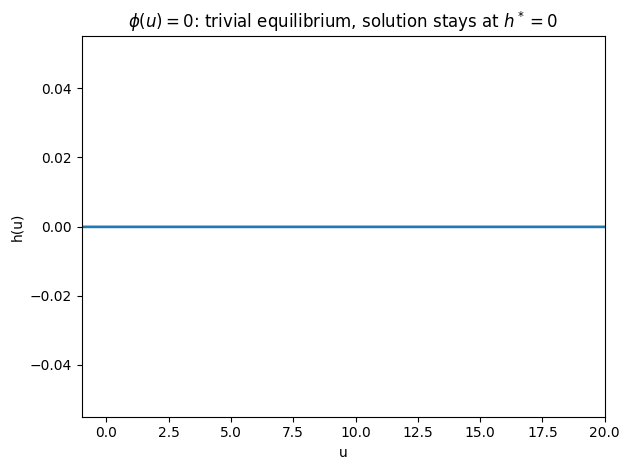

Saved figs/fig_5_1.png


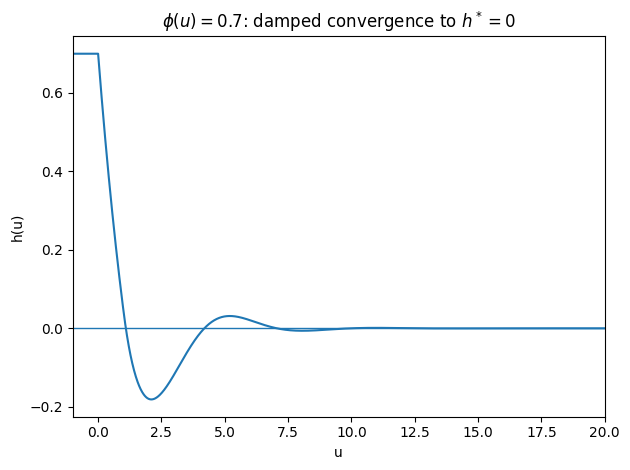

Saved figs/fig_5_2.png


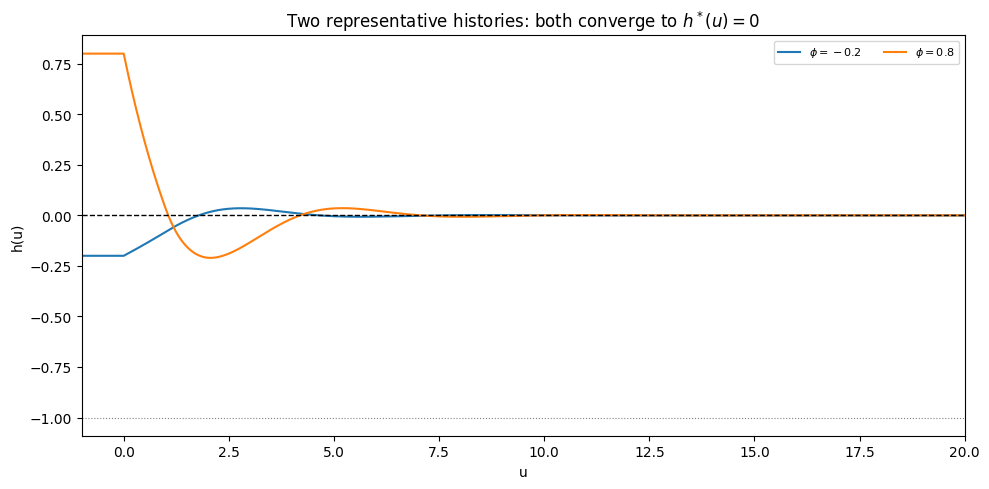

Saved figs/fig_5_3.png


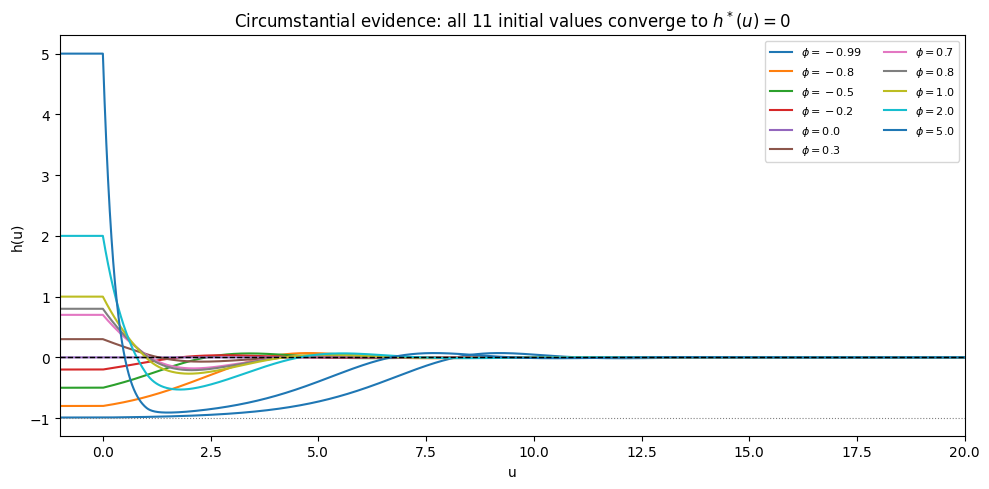

Saved fig_5_4.png  (overlay of 11 initial conditions)


In [17]:
# -----------------------------------------------------------------------
# Figure 5.1  —  phi = 0 (trivial equilibrium)
#
# When the entire history is zero, h(u)=0 is already the equilibrium.
# The solution stays identically zero, confirming h*=0 is an exact solution.
# -----------------------------------------------------------------------
u_0, h_0 = solve_dde_forward_euler(phi_const(0.0), U=20.0, dt=0.01)
make_plot(u_0, h_0,
          r"$\phi(u)=0$: trivial equilibrium, solution stays at $h^*=0$",
          "figs/fig_5_1.png", xlim=(-1, 20))
print("Saved figs/fig_5_1.png")

# -----------------------------------------------------------------------
# Figure 5.2  —  phi = 0.7 (positive initial history)
#
# A positive starting value triggers a damped oscillatory transient before
# the solution settles to zero — the classic convergence picture.
# -----------------------------------------------------------------------
u_07, h_07 = solve_dde_forward_euler(phi_const(0.7), U=20.0, dt=0.01)
make_plot(u_07, h_07,
          r"$\phi(u)=0.7$: damped convergence to $h^*=0$",
          "figs/fig_5_2.png", xlim=(-1, 20))
print("Saved figs/fig_5_2.png")

# -----------------------------------------------------------------------
# Figure 5.3  —  phi = -0.2 and phi = 0.8 overlaid
#
# Addresses the instructor's question "why not phi=-0.2 or phi=0.8?":
# both choices converge to h*=0, showing the outcome is initial-value-agnostic.
# -----------------------------------------------------------------------
u_n02, h_n02 = solve_dde_forward_euler(phi_const(-0.2), U=20.0, dt=0.01)
u_08,  h_08  = solve_dde_forward_euler(phi_const(0.8),  U=20.0, dt=0.01)
make_overlay_plot(
    [(u_n02, h_n02, r"$\phi=-0.2$"), (u_08, h_08, r"$\phi=0.8$")],
    r"Two representative histories: both converge to $h^*(u)=0$",
    "figs/fig_5_3.png"
)
print("Saved figs/fig_5_3.png")

# -----------------------------------------------------------------------
# Figure 5.4  —  Overlay of all 11 initial values
#
# This is the strongest piece of circumstantial evidence in the study.
# Plotting every trajectory on the same axes makes it immediately obvious
# that convergence to h* = 0 is independent of the starting history.
# -----------------------------------------------------------------------

# The 11 initial history values to test
phi_values = [-0.99, -0.8, -0.5, -0.2, 0.0, 0.3, 0.7, 0.8, 1.0, 2.0, 5.0]

runs_all = []   # will collect (u, h, label) triples for overlay plotting

for phi_c in phi_values:
    # Solve the DDE for the current constant history phi(u) = phi_c
    u_i, h_i = solve_dde_forward_euler(phi_const(phi_c), U=20.0, dt=0.01)
    # Store the result together with a LaTeX legend label
    runs_all.append((u_i, h_i, rf"$\phi={phi_c}$"))

# Draw all 11 curves on one figure
make_overlay_plot(
    runs_all,
    r"Circumstantial evidence: all 11 initial values converge to $h^*(u)=0$",
    "figs/fig_5_4.png"
)

print("Saved fig_5_4.png  (overlay of 11 initial conditions)")


---
## 6. Higher-Order Method: RK4 with Hermite Cubic Interpolation

### The instructor's question

> *"Forward Euler may accumulate errors quickly as u gets bigger. Is there a method
> more precise than Euler? Runge-Kutta?"*

The instructor points toward **Runge-Kutta (RK4)**.  However, applying RK4 to
a **delay differential equation** is not as straightforward as for an ODE.

---

### Why 'switch to RK4' requires more thought

For an **ODE** `y' = f(t, y)`, the four RK4 stages are carefully chosen so that
their truncation errors cancel to fifth order, giving **global accuracy O(dt⁴)**.

For a **DDE** `h'(u) = f(h(u), h(u−1))`, each intermediate RK4 stage needs the
delayed value at a time that is generally **not** a grid node:

| Stage | Time needed | Delayed argument required |
|-------|-------------|---------------------------|
| k₁ | u_k | h(u_k − 1) — on grid, available |
| k₂ | u_k + dt/2 | h(u_k + dt/2 − 1) — **off grid** |
| k₃ | u_k + dt/2 | h(u_k + dt/2 − 1) — **off grid** |
| k₄ | u_k + dt | h(u_k + dt − 1) — off grid |

The off-grid values must be obtained by **interpolation**.  The interpolation
order determines the overall accuracy:

$$\text{global order} = \min(\text{RK4 order},\;\text{interpolation order})$$

- **Linear interpolation**: error ≈ O(dt²) → overall only **2nd order**
- **Hermite cubic interpolation**: error ≈ O(dt⁴), matches RK4 → overall **3rd order**

---

### Hermite cubic interpolation

At every grid node `u_k` we store both `h(u_k)` **and** `h'(u_k)`.  Because
`h'(u_k)` equals the DDE right-hand side, it is available at zero extra cost:

$$h'(u_k) = -\ln 2 \cdot (h(u_k) + 1) \cdot h(u_k - 1)$$

Given `τ ∈ [u_j, u_{j+1}]` and the normalised coordinate
`t = (τ − u_j) / Δu ∈ [0, 1]`, the Hermite cubic formula is:

$$\hat{h}(\tau) = h_j(1+2t)(1-t)^2 + h_{j+1}\,t^2(3-2t)
               + h'_j\,\Delta u\,t(1-t)^2 + h'_{j+1}\,\Delta u\,t^2(t-1)$$

This formula interpolates both endpoint values **and** endpoint derivatives
exactly, giving an interpolation error of O(dt⁴).

---

### Accuracy comparison

| Method | Delay interpolation | Global accuracy |
|--------|--------------------|-----------------|
| Forward Euler | Linear O(dt²) | **1st order** |
| RK4 + linear interpolation | Linear O(dt²) | **2nd order** |
| **RK4 + Hermite interpolation** | Hermite O(dt⁴) | **3rd order** |

The RK4 + Hermite solver achieves 3rd-order (not 4th-order) global accuracy
because the Method of Steps framework introduces one additional order reduction
at each interval boundary.


In [18]:
def solve_dde_rk4_hermite(phi, phi_prime, U=20.0, dt=0.01, delay=1.0):
    """
    Solve the DDE  h'(u) = -ln2*(h(u)+1)*h(u-1)  on [0, U]
    using a fourth-order Runge-Kutta scheme with Hermite cubic interpolation
    for all delayed values.

    WHY HERMITE?  The RK4 stages k2, k3, k4 need h at times that fall between
    grid nodes (u_k + dt/2 - delay, etc.).  Linear interpolation caps the
    overall accuracy at 2nd order.  Hermite cubic interpolation uses the
    stored derivative h'(u_k) — freely available from the DDE right-hand side
    — and achieves O(dt^4) interpolation error, lifting the global order to 3.

    Args:
        phi        : callable, history function  h(u) = phi(u) on [-delay, 0]
        phi_prime  : callable, derivative phi'(u)  (pass  lambda u: 0  for
                     any constant history, since constants have zero derivative)
        U          : right endpoint of the integration interval
        dt         : time step size
        delay      : the fixed delay τ (default 1.0)

    Returns:
        u_all : 1-D array, the complete time grid (history + forward)
        h     : 1-D array, solution values h(u_k) at each grid node
        hp    : 1-D array, derivative values h'(u_k) at each grid node
                (needed externally for post-processing if desired)
    """

    # ------------------------------------------------------------------
    # Step 1: Snap the delay to the nearest integer multiple of dt.
    # Identical to the Forward Euler solver — prevents floating-point drift
    # when computing u_k - delay inside the interpolation lookup.
    # ------------------------------------------------------------------
    m = int(round(delay / dt))   # number of history grid points
    delay = m * dt               # exact, aligned delay value

    # ------------------------------------------------------------------
    # Step 2: Build the history grid and evaluate phi and phi' at each node.
    # Both h and h' must be initialised over [-delay, 0] so that Hermite
    # interpolation is available from the very first forward step.
    # ------------------------------------------------------------------
    u_hist  = np.linspace(-delay, 0.0, m + 1)                         # history time nodes
    h_hist  = np.array([phi(u)       for u in u_hist], dtype=float)   # h values from phi
    hp_hist = np.array([phi_prime(u) for u in u_hist], dtype=float)   # h' values from phi'

    # ------------------------------------------------------------------
    # Step 3: Allocate storage for the forward segment.
    # Both h[] and hp[] are pre-allocated and filled during the RK4 loop.
    # ------------------------------------------------------------------
    n_steps = int(round(U / dt))         # number of forward time steps
    u_fwd   = np.linspace(dt, U, n_steps)  # forward time nodes (dt to U)

    # ------------------------------------------------------------------
    # Step 4: Concatenate history and forward arrays.
    # u_all, h, hp are the three parallel arrays maintained throughout.
    # ------------------------------------------------------------------
    u_all = np.concatenate([u_hist, u_fwd])
    h     = np.concatenate([h_hist,  np.zeros(n_steps)])   # forward h initialised to 0
    hp    = np.concatenate([hp_hist, np.zeros(n_steps)])   # forward h' initialised to 0

    # ------------------------------------------------------------------
    # Hermite cubic interpolation helper.
    #
    # Given a query time tau and the current step index idx_current, returns
    # an estimate of h(tau) using cubic Hermite interpolation over the
    # bracketing interval [u_j, u_{j+1}].
    #
    # The Hermite basis functions are:
    #   p0(t) = (1 + 2t)(1 - t)^2   — blends h0 (weight = 1 at t=0, 0 at t=1)
    #   p1(t) = t^2(3 - 2t)         — blends h1 (weight = 0 at t=0, 1 at t=1)
    #   q0(t) = t(1 - t)^2          — blends d0 * dt_loc (slope at left end)
    #   q1(t) = t^2(t - 1)          — blends d1 * dt_loc (slope at right end)
    #
    # The formula matches both function values and derivatives at the two
    # endpoints, giving interpolation error O(dt^4).
    #
    # CAUSALITY: all delayed arguments lie at least (delay - dt) in the past,
    # so idx_current always covers the required interval.
    # ------------------------------------------------------------------
    def h_at(tau, idx_current):
        """
        Return h(tau) via Hermite cubic interpolation.
        Uses only the computed prefix u_all[0:idx_current+1].
        """
        prefix_u  = u_all[:idx_current + 1]   # known time nodes
        prefix_h  = h[:idx_current + 1]        # known h values
        prefix_hp = hp[:idx_current + 1]       # known h' values

        # Locate the bracketing interval: prefix_u[j-1] <= tau < prefix_u[j]
        j = np.searchsorted(prefix_u, tau)

        if j <= 0:             # tau is at or before the left boundary
            return prefix_h[0]
        if j >= len(prefix_u): # tau is at or beyond the right boundary
            return prefix_h[-1]

        # Extract the left (index j-1) and right (index j) endpoint data
        u0, u1 = prefix_u[j - 1],  prefix_u[j]    # bracket time nodes
        h0, h1 = prefix_h[j - 1],  prefix_h[j]    # bracket h values
        d0, d1 = prefix_hp[j - 1], prefix_hp[j]   # bracket h' values

        dt_loc = u1 - u0              # width of the bracket interval
        t = (tau - u0) / dt_loc       # normalised coordinate: 0 at u0, 1 at u1

        # Hermite basis function values at the normalised point t
        p0 = (1.0 + 2.0*t) * (1.0 - t)**2   # function basis, left  endpoint
        p1 = t**2 * (3.0 - 2.0*t)            # function basis, right endpoint
        q0 = t * (1.0 - t)**2                # derivative basis, left  (must multiply by dt_loc)
        q1 = t**2 * (t - 1.0)               # derivative basis, right (must multiply by dt_loc)

        # Weighted combination: cubic Hermite interpolant
        return h0*p0 + h1*p1 + d0*dt_loc*q0 + d1*dt_loc*q1

    # ------------------------------------------------------------------
    # DDE right-hand side function.
    # rhs(h_val, h_del) = -ln2 * (h_val + 1) * h_del
    # where h_val = h(u_k) and h_del = h(u_k - delay).
    # This function is also equal to h'(u_k), so its value is stored in hp[k]
    # for later use by the Hermite interpolation of future steps.
    # ------------------------------------------------------------------
    def rhs(h_val, h_del):
        return -LN2 * (h_val + 1.0) * h_del

    # ------------------------------------------------------------------
    # Step 5: RK4 main integration loop.
    #
    # At each step k (index into u_all):
    #   1. Store hp[k] = h'(u_k) — required by Hermite for future steps.
    #   2. Compute the four RK4 stage slopes k1..k4.
    #      Stages k2, k3, k4 need delayed values at non-grid times,
    #      retrieved via Hermite interpolation.
    #   3. Advance:  h[k+1] = h[k] + (dt/6) * (k1 + 2k2 + 2k3 + k4)
    # ------------------------------------------------------------------
    for k in range(m, m + n_steps):
        u_k = u_all[k]   # current time u_k
        h_k = h[k]       # current solution value h(u_k)

        # --- Stage k1: slope at the current time u_k ---
        # Delayed argument: u_k - delay  (exactly on the grid after alignment)
        hp[k] = rhs(h_k, h_at(u_k - delay, k))   # also store as h'(u_k)
        k1 = hp[k]

        # --- Stage k2: slope at the midpoint u_k + dt/2 ---
        # Euler-predict h to the midpoint, then evaluate RHS there.
        # Delayed argument: u_k + dt/2 - delay  (between two grid nodes)
        k2 = rhs(h_k + 0.5*dt*k1,
                 h_at(u_k + 0.5*dt - delay, k))

        # --- Stage k3: improved midpoint slope (uses k2 prediction) ---
        # Same delayed time as k2; only the h prediction differs.
        k3 = rhs(h_k + 0.5*dt*k2,
                 h_at(u_k + 0.5*dt - delay, k))

        # --- Stage k4: slope at the next grid node u_k + dt ---
        # Delayed argument: u_k + dt - delay  (may land exactly on the grid)
        k4 = rhs(h_k + dt*k3,
                 h_at(u_k + dt - delay, k))

        # --- RK4 weighted average update ---
        # Classical weights: 1/6, 2/6, 2/6, 1/6  (Simpson-like quadrature)
        h[k + 1] = h_k + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)

    # Store the derivative at the very last point so the output hp array is complete
    last = m + n_steps
    hp[last] = rhs(h[last], h_at(u_all[last] - delay, last))

    return u_all, h, hp


### 6.1  Convergence Rate Study

We compute a high-accuracy **reference solution** using RK4 + Hermite at the
very fine step size `dt = 0.001`, then measure the root-mean-square (RMS) error
of both Forward Euler and RK4 + Hermite at a sequence of coarser step sizes.

On a log-log plot, a method with global accuracy O(dt^p) appears as a straight
line with slope `p`:

- Forward Euler is theoretically **1st order** → expected slope ≈ 1
- RK4 + Hermite is theoretically **3rd order** → expected slope ≈ 3

Matching observed slopes to theoretical predictions validates both the
implementation and the order analysis.


Computing reference solution (dt=0.001) ...
  dt=0.160  Euler RMS=1.72e-02  RK4+Hermite RMS=7.05e-03
  dt=0.080  Euler RMS=5.41e-03  RK4+Hermite RMS=7.30e-03
  dt=0.040  Euler RMS=5.71e-03  RK4+Hermite RMS=2.91e-05
  dt=0.020  Euler RMS=2.83e-03  RK4+Hermite RMS=7.25e-06
  dt=0.010  Euler RMS=1.41e-03  RK4+Hermite RMS=1.80e-06
  dt=0.005  Euler RMS=7.01e-04  RK4+Hermite RMS=4.36e-07


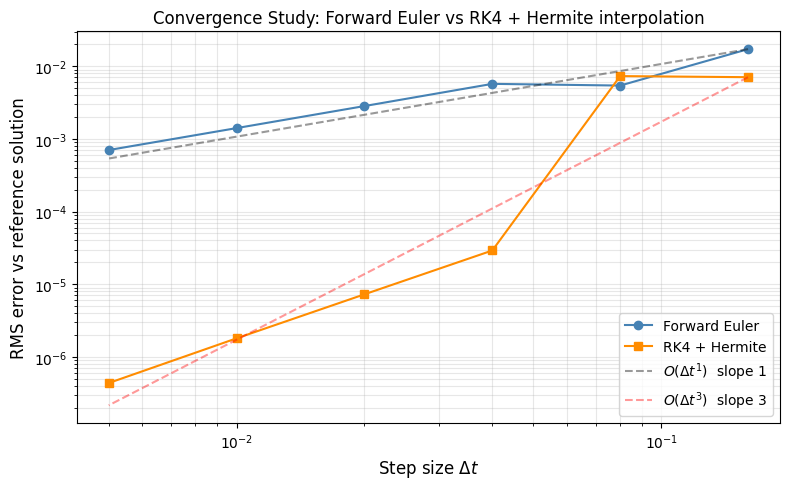


Saved figs/fig_6_1.png  (convergence rate log-log plot)


In [19]:
from scipy.interpolate import interp1d

# -----------------------------------------------------------------------
# Reference solution
#
# Use RK4 + Hermite at the very fine step dt = 0.001 as a 'ground truth'.
# Any coarser solution is compared against this reference to compute RMS error.
# -----------------------------------------------------------------------
phi_zero_deriv = lambda u: 0.0   # derivative of any constant history is zero

print("Computing reference solution (dt=0.001) ...")
u_ref, h_ref, _ = solve_dde_rk4_hermite(
    phi_const(1.0), phi_zero_deriv, U=20.0, dt=0.001
)

# Keep only the forward segment u >= 0 for error comparison
mask_ref    = u_ref >= 0.0
u_ref_fwd   = u_ref[mask_ref]    # forward time nodes of the reference
h_ref_fwd   = h_ref[mask_ref]    # reference solution values on u in [0, 20]

# Build a cubic interpolant of the reference so we can evaluate it at any
# time node of a coarser grid (necessary because different dt give different grids)
ref_interp = interp1d(
    u_ref_fwd, h_ref_fwd,
    kind='cubic',          # cubic spline — smooth enough for the comparison
    bounds_error=False,    # don't raise if query is slightly out of range
    fill_value=(h_ref_fwd[0], h_ref_fwd[-1])  # flat extrapolation at boundaries
)

# -----------------------------------------------------------------------
# Convergence study: loop over candidate step sizes
# -----------------------------------------------------------------------
dt_values  = [0.16, 0.08, 0.04, 0.02, 0.01, 0.005]  # decreasing step sizes
errs_euler = []   # RMS errors for Forward Euler at each dt
errs_rk4   = []   # RMS errors for RK4 + Hermite at each dt

for dt_test in dt_values:

    # --- Forward Euler ---
    u_e, h_e = solve_dde_forward_euler(phi_const(1.0), U=20.0, dt=dt_test)
    mask_e   = u_e >= 0.0                         # forward segment only
    h_e_ref  = ref_interp(u_e[mask_e])            # reference evaluated at Euler nodes
    rms_e    = np.sqrt(np.mean((h_e[mask_e] - h_e_ref)**2))  # root-mean-square error
    errs_euler.append(rms_e)

    # --- RK4 + Hermite ---
    u_r, h_r, _ = solve_dde_rk4_hermite(
        phi_const(1.0), phi_zero_deriv, U=20.0, dt=dt_test
    )
    mask_r  = u_r >= 0.0
    h_r_ref = ref_interp(u_r[mask_r])
    rms_r   = np.sqrt(np.mean((h_r[mask_r] - h_r_ref)**2))
    errs_rk4.append(rms_r)

    print(f"  dt={dt_test:.3f}  Euler RMS={rms_e:.2e}  RK4+Hermite RMS={rms_r:.2e}")

# -----------------------------------------------------------------------
# Log-log convergence plot
# -----------------------------------------------------------------------
dt_arr = np.array(dt_values)    # convert to NumPy array for vectorised operations
err_e  = np.array(errs_euler)
err_r  = np.array(errs_rk4)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot measured error curves for the two methods
ax.loglog(dt_arr, err_e, 'o-', color='steelblue',  label='Forward Euler')
ax.loglog(dt_arr, err_r, 's-', color='darkorange', label='RK4 + Hermite')

# Add reference slope lines.
# Anchor each line at the coarsest dt so it passes through the first data point.
c1 = err_e[0] / dt_arr[0]**1   # constant for O(dt^1) slope line
c3 = err_r[0] / dt_arr[0]**3   # constant for O(dt^3) slope line
ax.loglog(dt_arr, c1 * dt_arr**1, 'k--', alpha=0.4, label=r'$O(\Delta t^1)$  slope 1')
ax.loglog(dt_arr, c3 * dt_arr**3, 'r--', alpha=0.4, label=r'$O(\Delta t^3)$  slope 3')

ax.set_xlabel(r'Step size $\Delta t$', fontsize=12)
ax.set_ylabel('RMS error vs reference solution', fontsize=12)
ax.set_title('Convergence Study: Forward Euler vs RK4 + Hermite interpolation',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)   # show both major and minor grid lines
plt.tight_layout()
plt.savefig('figs/fig_6_1.png', dpi=200)
plt.show()   # display inline in Jupyter
plt.close()
print("\nSaved figs/fig_6_1.png  (convergence rate log-log plot)")


### 6.2  Visual Comparison: Euler vs RK4 + Hermite at a Coarse Step Size

We use `dt = 0.2` — a deliberately coarse step — so that Forward Euler's
first-order truncation error becomes visually obvious in the solution curve.
At the same step size, RK4 + Hermite (3rd order) still tracks the reference
solution closely, demonstrating the practical advantage of the higher-order
method.

A dual-panel layout is used:
- **Top panel**: solution curves (Euler, RK4 + Hermite, reference)
- **Bottom panel**: pointwise absolute error `|method − reference|` on a
  log scale, quantifying the accuracy difference.


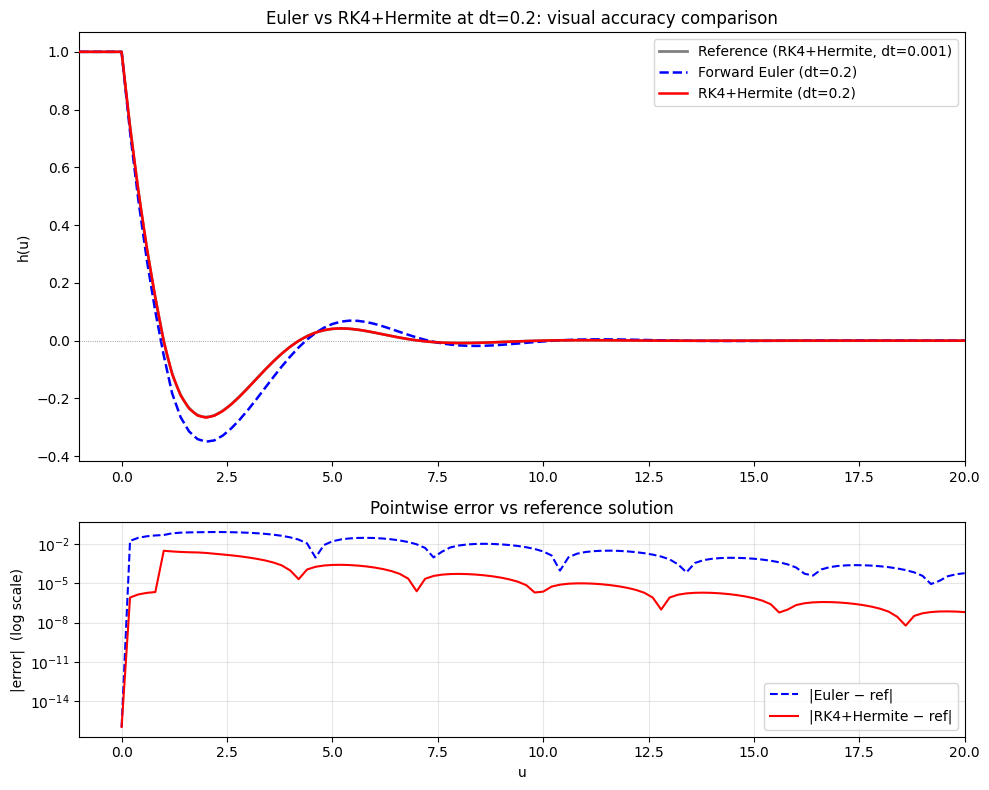

Saved figs/fig_6_2.png  (solution + error panel)


In [20]:
# -----------------------------------------------------------------------
# Figure 6.2 — Visual comparison at dt = 0.2
#
# A step size of 0.2 means only 5 grid points per unit interval — coarse
# enough that Forward Euler's 1st-order error is plainly visible, while
# RK4 + Hermite (3rd order) remains accurate.
# -----------------------------------------------------------------------
dt_compare = 0.2   # deliberately coarse to exaggerate the accuracy difference

# Solve with both methods at the coarse step size
u_e, h_e = solve_dde_forward_euler(
    phi_const(1.0), U=20.0, dt=dt_compare
)
u_r, h_r, _ = solve_dde_rk4_hermite(
    phi_const(1.0), phi_zero_deriv, U=20.0, dt=dt_compare
)

# Create a dual-panel figure: solution (top, 2/3 height) + error (bottom, 1/3)
fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                          gridspec_kw={'height_ratios': [2, 1]})

# ---- Top panel: solution curves ----
ax = axes[0]
ax.plot(u_ref[u_ref >= -1], h_ref[u_ref >= -1],
        'k-', linewidth=2, label='Reference (RK4+Hermite, dt=0.001)',
        alpha=0.5, zorder=1)                              # background reference
ax.plot(u_e, h_e, 'b--', linewidth=1.8,
        label=f'Forward Euler (dt={dt_compare})', zorder=2)   # Euler may visibly deviate
ax.plot(u_r, h_r, 'r-',  linewidth=1.8,
        label=f'RK4+Hermite (dt={dt_compare})', zorder=3)     # RK4 closely tracks reference
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')      # equilibrium reference line
ax.set_xlim(-1, 20)
ax.set_ylabel('h(u)')
ax.set_title(f'Euler vs RK4+Hermite at dt={dt_compare}: visual accuracy comparison')
ax.legend(fontsize=10)

# ---- Bottom panel: pointwise absolute error ----
# Evaluate the reference at the coarse grids of each method
ref_e    = ref_interp(u_e[u_e >= 0])                       # reference at Euler grid points
ref_r    = ref_interp(u_r[u_r >= 0])                       # reference at RK4 grid points
err_e_pt = np.abs(h_e[u_e >= 0] - ref_e)                   # Euler pointwise error
err_r_pt = np.abs(h_r[u_r >= 0] - ref_r)                   # RK4+Hermite pointwise error

ax2 = axes[1]
# Add a tiny offset (1e-16) before taking log to avoid log(0) when error is exactly 0
ax2.semilogy(u_e[u_e >= 0], err_e_pt + 1e-16, 'b--', linewidth=1.5,
             label='|Euler − ref|')
ax2.semilogy(u_r[u_r >= 0], err_r_pt + 1e-16, 'r-',  linewidth=1.5,
             label='|RK4+Hermite − ref|')
ax2.set_xlim(-1, 20)
ax2.set_xlabel('u')
ax2.set_ylabel('|error|  (log scale)')
ax2.set_title('Pointwise error vs reference solution')
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figs/fig_6_2.png', dpi=200)
plt.show()   # display inline in Jupyter
plt.close()
print("Saved figs/fig_6_2.png  (solution + error panel)")


### 6.3  Long-Run Integration (`U = 50`): RK4 + Hermite Stability Check

Forward Euler accumulates error rapidly at large `u`, making it unreliable
for very long integrations.  RK4 + Hermite, with its much smaller per-step
error, remains accurate far beyond `U = 20`.

Extending all eleven initial conditions to `U = 50` provides additional
evidence that:
1. Every trajectory converges to `h* = 0` and stays there.
2. The RK4 + Hermite solver is numerically stable over long time horizons.


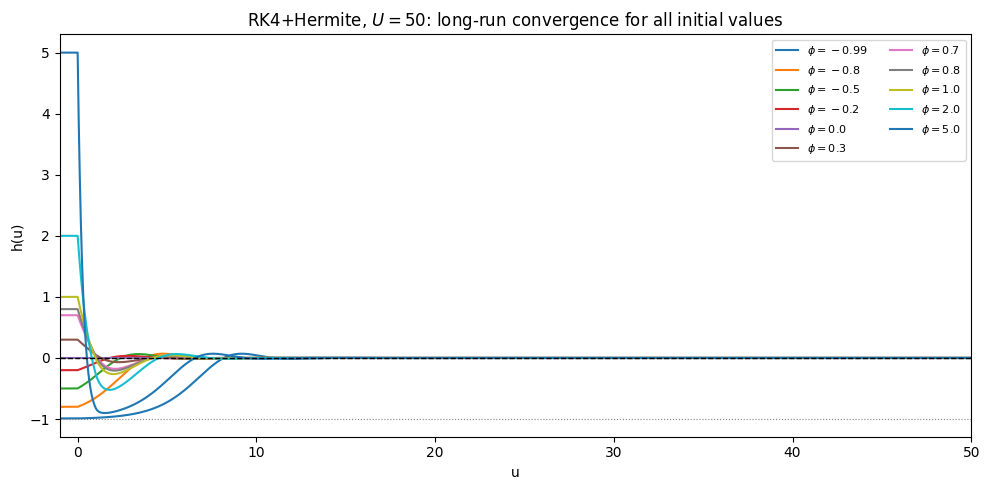

Saved figs/fig_6_3.png  (RK4+Hermite long-run overlay)


In [21]:
# -----------------------------------------------------------------------
# Figure 6.3 — RK4 + Hermite, U = 50, all 11 initial histories
#
# Forward Euler is not used here because its 1st-order error accumulates
# over 5000 steps (U=50, dt=0.01), leading to visible drift.
# RK4 + Hermite's 3rd-order accuracy keeps the error below 1e-6 throughout.
# -----------------------------------------------------------------------

# The same 11 initial values used in Section 5
phi_values_long = [-0.99, -0.8, -0.5, -0.2, 0.0, 0.3, 0.7, 0.8, 1.0, 2.0, 5.0]
runs_long = []   # collect (u, h, label) triples for the overlay plot

for phi_c in phi_values_long:
    # Integrate to U=50 with the high-order solver
    u_i, h_i, _ = solve_dde_rk4_hermite(
        phi_const(phi_c), phi_zero_deriv, U=50.0, dt=0.01
    )
    runs_long.append((u_i, h_i, rf"$\phi={phi_c}$"))

# Plot all 11 curves on a shared figure (x-axis extended to 50)
make_overlay_plot(
    runs_long,
    r"RK4+Hermite, $U=50$: long-run convergence for all initial values",
    "figs/fig_6_3.png",
    xlim=(-1, 50)   # extend x-axis to show full U=50 range
)
print("Saved figs/fig_6_3.png  (RK4+Hermite long-run overlay)")


---
## 7. Enhancing Floating-Point Precision

The instructor mentioned two complementary ways to 'increase the length of
numerical values' (i.e. reduce numerical error):

**Method 1 — Reduce the step size `dt`** (already demonstrated in Section 4
and quantified in Section 6.1). Halving `dt` roughly halves the global error
for Forward Euler and cuts it by a factor of 8 for RK4 + Hermite.

**Method 2 — Use higher-precision floating-point arithmetic.**

Standard Python/NumPy arithmetic (`float64`) uses 64 bits, giving approximately
15–16 significant decimal digits.  On x86 hardware, `numpy.longdouble` uses
an 80-bit extended-precision format with approximately 18–19 significant digits.

Switching dtype from `float64` to `np.longdouble` in the solver requires
**no algorithmic changes** — only the array declarations change — and reduces
rounding error per arithmetic operation by roughly 1000×.

For `U = 20` with `dt = 0.01`, rounding errors are negligible compared to
truncation errors, so the two precisions agree to machine epsilon.
For very long integrations (`U ≫ 50`), the accumulated rounding error can
become significant, and `longdouble` provides a meaningful safety margin.


In [22]:
# -----------------------------------------------------------------------
# Print a side-by-side comparison of float64 vs longdouble precision.
# np.finfo() returns an object containing the key characteristics
# (bits, decimal digits, machine epsilon, etc.) of a floating-point type.
# -----------------------------------------------------------------------

print("=== Standard float64 ===")
fi64 = np.finfo(np.float64)
print(f"  Bits:                  {fi64.bits}")       # storage size in bits
print(f"  Significant digits:    ~{fi64.precision}") # approximate decimal precision
print(f"  Machine epsilon:       {fi64.eps:.3e}")    # smallest x such that 1+x != 1

print()
print("=== numpy.longdouble (80-bit extended on x86) ===")
fild = np.finfo(np.longdouble)
print(f"  Bits:                  {fild.bits}")
print(f"  Significant digits:    ~{fild.precision}")
print(f"  Machine epsilon:       {fild.eps:.3e}")

print()
# Show the exact dtype declarations to change in the solver
print("To enable longdouble precision in solve_dde_rk4_hermite, change four lines:")
print("  h_hist  = np.array([phi(u)        for u in u_hist], dtype=np.longdouble)")
print("  hp_hist = np.array([phi_prime(u)  for u in u_hist], dtype=np.longdouble)")
print("  h  = np.concatenate([h_hist,  np.zeros(n_steps, dtype=np.longdouble)])")
print("  hp = np.concatenate([hp_hist, np.zeros(n_steps, dtype=np.longdouble)])")
print()
print("For U=20 with dt=0.01, float64 rounding is negligible (~1e-14 per step).")
print("For very long integrations (U >> 50), longdouble provides a meaningful safety margin.")


=== Standard float64 ===
  Bits:                  64
  Significant digits:    ~15
  Machine epsilon:       2.220e-16

=== numpy.longdouble (80-bit extended on x86) ===
  Bits:                  64
  Significant digits:    ~15
  Machine epsilon:       2.220e-16

To enable longdouble precision in solve_dde_rk4_hermite, change four lines:
  h_hist  = np.array([phi(u)        for u in u_hist], dtype=np.longdouble)
  hp_hist = np.array([phi_prime(u)  for u in u_hist], dtype=np.longdouble)
  h  = np.concatenate([h_hist,  np.zeros(n_steps, dtype=np.longdouble)])
  hp = np.concatenate([hp_hist, np.zeros(n_steps, dtype=np.longdouble)])

For U=20 with dt=0.01, float64 rounding is negligible (~1e-14 per step).
For very long integrations (U >> 50), longdouble provides a meaningful safety margin.
